In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.data import create_dummy_patient_data
from src.experiment import run_tree_experiment
from src.evaluation import plot_confusion_matrix, show_classification_report

In [2]:
df, feature_names, classes = create_dummy_patient_data()
df.head()


,age,heart_rate,systolic_bp,diastolic_bp,spo2,resp_rate,glucose,lactate,creatinine,hemoglobin,wbc,platelets,disease_risk
0,-0.997374,-1.445264,0.494859,-0.799365,2.149282,0.747528,0.750917,-1.804360,1.459794,-0.381958,0.802052,-0.482308,0
1,3.296716,3.071636,-1.254011,-1.031008,-1.809797,2.117675,-0.984634,-1.505780,-1.991836,-0.490332,0.517977,-0.208309,3
2,0.306845,0.559454,0.830793,0.665780,4.063102,0.373564,-1.104323,-2.500481,3.098752,0.630220,1.287933,-0.573542,0
3,-1.659225,-1.343366,-0.428302,-0.100735,0.741445,0.962378,-0.172409,-1.357380,2.181178,-0.395934,-1.632009,1.111931,0
4,-0.071542,-1.030548,1.113612,-0.172948,0.137395,-0.476298,-0.546056,-1.630697,3.172656,-1.279302,-2.225972,0.940137,2


In [3]:
results = run_tree_experiment(
    df=df,
    target_col="disease_risk",
    feature_names=feature_names,
    results_dir="results/dummy_patient_data"
)

Decision Tree Accuracy: 0.75225


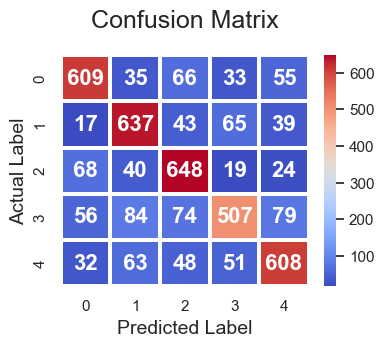

,precision,recall,f1-score,support
0,0.778772,0.763158,0.770886,798.000000
1,0.741560,0.795256,0.767470,801.000000
2,0.737201,0.811014,0.772348,799.000000
3,0.751111,0.633750,0.687458,800.000000
4,0.755280,0.758105,0.756689,802.000000
accuracy,0.752250,0.752250,0.752250,0.752250
macro avg,0.752785,0.752256,0.750970,4000.000000
weighted avg,0.752774,0.752250,0.750962,4000.000000


In [4]:
dt_results = results["Decision Tree"]

print("Decision Tree Accuracy:", dt_results["accuracy"])

plot_confusion_matrix(
    dt_results["y_test"],
    dt_results["predictions"],
    classes
)

show_classification_report(
    dt_results["y_test"],
    dt_results["predictions"]
)

Random Forest Accuracy: 0.78775


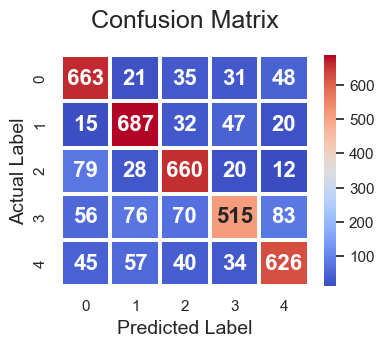

,precision,recall,f1-score,support
0,0.772727,0.830827,0.800725,798.000000
1,0.790564,0.857678,0.822754,801.000000
2,0.788530,0.826033,0.806846,799.000000
3,0.795981,0.643750,0.711818,800.000000
4,0.793409,0.780549,0.786926,802.000000
accuracy,0.787750,0.787750,0.787750,0.787750
macro avg,0.788242,0.787767,0.785814,4000.000000
weighted avg,0.788253,0.787750,0.785811,4000.000000


In [5]:
rf_results = results["Random Forest"]

print("Random Forest Accuracy:", rf_results["accuracy"])

plot_confusion_matrix(
    rf_results["y_test"],
    rf_results["predictions"],
    classes
)

show_classification_report(
    rf_results["y_test"],
    rf_results["predictions"]
)

In [6]:
rf_results["feature_importance"]

,feature,importance
5,resp_rate,0.158613
1,heart_rate,0.153218
4,spo2,0.142560
9,hemoglobin,0.134609
0,age,0.119270
10,wbc,0.113135
7,lactate,0.083247
8,creatinine,0.080411
2,systolic_bp,0.003946
3,diastolic_bp,0.003775
